In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv("../data/clean_sales_data.csv")

In [4]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Cost_Price,Discount,City,State,Region,Salesperson,Payment_Mode
0,ORD3526,2026-03-04,C0223,Sneha Mishra,Office Chair,Furniture,2.0,12000.0,8500,10.0,Gorakhpur,Uttar Pradesh,North,Sneha,UPI
1,ORD3923,2026-03-01,C0212,Karan Agarwal,Notebook,Stationery,1.0,120.0,65,10.0,Delhi,Delhi,North,Priya,Debit Card
2,ORD1890,2026-06-24,C0015,Rahul Yadav,Smartphone,Electronics,1.0,28000.0,22000,0.0,Delhi,Delhi,North,Neha,UPI
3,ORD1658,2026-08-02,C0467,Kavita Singh,Notebook,Stationery,5.0,120.0,65,10.0,Kolkata,West Bengal,East,Neha,Net Banking
4,ORD5317,2026-02-06,C0979,Ravi Sharma,Office Chair,Furniture,4.0,12000.0,8500,20.0,Jaipur,Rajasthan,North,Karan,Net Banking


## 1 Checking the basic validation

In [5]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Shape: (5000, 15)
Missing values: 0
Duplicates: 0


Checking
 Data Types

In [6]:
df.dtypes

Order_ID             str
Order_Date           str
Customer_ID          str
Customer_Name        str
Product              str
Category             str
Quantity         float64
Unit_Price       float64
Cost_Price         int64
Discount         float64
City                 str
State                str
Region               str
Salesperson          str
Payment_Mode         str
dtype: object

order_date datatypes : str -> datetime


In [7]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [8]:
df.dtypes

Order_ID                    str
Order_Date       datetime64[us]
Customer_ID                 str
Customer_Name               str
Product                     str
Category                    str
Quantity                float64
Unit_Price              float64
Cost_Price                int64
Discount                float64
City                        str
State                       str
Region                      str
Salesperson                 str
Payment_Mode                str
dtype: object

Create Business Metrics

Revenue

In [9]:
df["Revenue"] = df["Quantity"] * df["Unit_Price"]

Cost


In [10]:
df["Cost"] = df["Quantity"] * df["Cost_Price"]

Profit

In [11]:
df["Profit"] = df["Revenue"] - df["Cost"]

Profit Margin

In [12]:
df["Profit_Margin"] = np.where(
    df["Revenue"] != 0,
    (df["Profit"] / df["Revenue"]) * 100,
    0
)

In [13]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Cost_Price,Discount,City,State,Region,Salesperson,Payment_Mode,Revenue,Cost,Profit,Profit_Margin
0,ORD3526,2026-03-04,C0223,Sneha Mishra,Office Chair,Furniture,2.0,12000.0,8500,10.0,Gorakhpur,Uttar Pradesh,North,Sneha,UPI,24000.0,17000.0,7000.0,29.166667
1,ORD3923,2026-03-01,C0212,Karan Agarwal,Notebook,Stationery,1.0,120.0,65,10.0,Delhi,Delhi,North,Priya,Debit Card,120.0,65.0,55.0,45.833333
2,ORD1890,2026-06-24,C0015,Rahul Yadav,Smartphone,Electronics,1.0,28000.0,22000,0.0,Delhi,Delhi,North,Neha,UPI,28000.0,22000.0,6000.0,21.428571
3,ORD1658,2026-08-02,C0467,Kavita Singh,Notebook,Stationery,5.0,120.0,65,10.0,Kolkata,West Bengal,East,Neha,Net Banking,600.0,325.0,275.0,45.833333
4,ORD5317,2026-02-06,C0979,Ravi Sharma,Office Chair,Furniture,4.0,12000.0,8500,20.0,Jaipur,Rajasthan,North,Karan,Net Banking,48000.0,34000.0,14000.0,29.166667


Calculate Our First KPI Summary

In [14]:
total_orders = len(df)
total_units = df["Quantity"].sum()
total_revenue = df["Revenue"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_revenue) * 100
average_order_value = total_revenue / total_orders

In [15]:
print("Total Orders:", total_orders)
print("Total Units Sold:", total_units)
print("Total Revenue:", round(total_revenue, 2))
print("Total Cost:", round(total_cost, 2))
print("Total Profit:", round(total_profit, 2))
print("Profit Margin:", round(profit_margin, 2), "%")
print("Average Order Value:", round(average_order_value, 2))

Total Orders: 5000
Total Units Sold: 20103.0
Total Revenue: 296176220.0
Total Cost: 229533135.0
Total Profit: 66643085.0
Profit Margin: 22.5 %
Average Order Value: 59235.24


In [16]:
df["Discount"].describe()

count    5000.000000
mean        9.905000
std         7.077852
min         0.000000
25%         5.000000
50%        10.000000
75%        15.000000
max        20.000000
Name: Discount, dtype: float64

Create a KPI DataFrame

In [17]:
kpis = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Total Units Sold",
        "Total Revenue",
        "Total Cost",
        "Total Profit",
        "Profit Margin",
        "Average Order Value"
    ],
    "Value": [
        total_orders,
        total_units,
        total_revenue,
        total_cost,
        total_profit,
        profit_margin,
        average_order_value
    ]
})

kpis

,KPI,Value
0,Total Orders,5.000000e+03
1,Total Units Sold,2.010300e+04
2,Total Revenue,2.961762e+08
3,Total Cost,2.295331e+08
4,Total Profit,6.664308e+07
5,Profit Margin,2.250116e+01
6,Average Order Value,5.923524e+04


Calculate Net Revenue

In [18]:
df["Net_Revenue"] = (
    df["Revenue"] * (1 - df["Discount"] / 100)
)

Calculate Net Profit

In [19]:
df["Net_Profit"] = df["Net_Revenue"] - df["Cost"]


# And profit margin:
df["Net_Profit_Margin"] = np.where(
    df["Net_Revenue"] != 0,
    (df["Net_Profit"] / df["Net_Revenue"]) * 100,
    0
)

Recalculate Our Real KPIs

In [20]:
total_net_revenue = df["Net_Revenue"].sum()
total_net_profit = df["Net_Profit"].sum()

net_profit_margin = (
    total_net_profit / total_net_revenue
) * 100

average_net_order_value = (
    total_net_revenue / total_orders
)

print("Gross Revenue:", round(total_revenue, 2))
print("Net Revenue:", round(total_net_revenue, 2))
print("Total Cost:", round(total_cost, 2))
print("Net Profit:", round(total_net_profit, 2))
print("Net Profit Margin:", round(net_profit_margin, 2), "%")
print("Average Net Order Value:", round(average_net_order_value, 2))

Gross Revenue: 296176220.0
Net Revenue: 267607482.5
Total Cost: 229533135.0
Net Profit: 38074347.5
Net Profit Margin: 14.23 %
Average Net Order Value: 53521.5


## 2. Sales Trend Analysis

Create monthly analysis

In [21]:
monthly_sales = (
    df.groupby(df["Order_Date"].dt.to_period("M"))
      .agg(
          Orders=("Order_ID", "count"),
          Units_Sold=("Quantity", "sum"),
          Gross_Revenue=("Revenue", "sum"),
          Net_Revenue=("Net_Revenue", "sum"),
          Profit=("Net_Profit", "sum")
      )
      .reset_index()
)

In [22]:
monthly_sales

,Order_Date,Orders,Units_Sold,Gross_Revenue,Net_Revenue,Profit
0,2026-01,636,2542.0,33588870.0,30452069.0,4436939.0
1,2026-02,546,2196.0,33625750.0,30706878.5,4825958.5
2,2026-03,668,2707.0,39283360.0,35241453.5,4731053.5
3,2026-04,636,2588.0,40800060.0,36999743.0,5095673.0
4,2026-05,662,2713.0,37168650.0,33254810.0,4685985.0
5,2026-06,648,2536.0,36748070.0,33251292.0,5019262.0
6,2026-07,614,2461.0,39158150.0,34954421.0,4383876.0
7,2026-08,584,2340.0,35667470.0,32619609.5,4865049.5
8,2026-09,1,4.0,480.0,432.0,172.0
9,2026-12,5,16.0,135360.0,126774.0,30379.0


In [23]:
monthly_sales["Order_Date"] = (
    monthly_sales["Order_Date"].astype(str)
)
monthly_sales


,Order_Date,Orders,Units_Sold,Gross_Revenue,Net_Revenue,Profit
0,2026-01,636,2542.0,33588870.0,30452069.0,4436939.0
1,2026-02,546,2196.0,33625750.0,30706878.5,4825958.5
2,2026-03,668,2707.0,39283360.0,35241453.5,4731053.5
3,2026-04,636,2588.0,40800060.0,36999743.0,5095673.0
4,2026-05,662,2713.0,37168650.0,33254810.0,4685985.0
5,2026-06,648,2536.0,36748070.0,33251292.0,5019262.0
6,2026-07,614,2461.0,39158150.0,34954421.0,4383876.0
7,2026-08,584,2340.0,35667470.0,32619609.5,4865049.5
8,2026-09,1,4.0,480.0,432.0,172.0
9,2026-12,5,16.0,135360.0,126774.0,30379.0


Find the best month

In [24]:
best_month = monthly_sales.loc[
    monthly_sales["Net_Revenue"].idxmax()
]

best_month

Order_Date          2026-04
Orders                  636
Units_Sold           2588.0
Gross_Revenue    40800060.0
Net_Revenue      36999743.0
Profit            5095673.0
Name: 3, dtype: object

In [25]:
best_profit_month = monthly_sales.loc[
    monthly_sales["Profit"].idxmax()
]

best_profit_month

Order_Date          2026-04
Orders                  636
Units_Sold           2588.0
Gross_Revenue    40800060.0
Net_Revenue      36999743.0
Profit            5095673.0
Name: 3, dtype: object

Find the worst month

In [26]:
worst_month = monthly_sales.loc[
    monthly_sales["Net_Revenue"].idxmin()
]

worst_month

Order_Date       2026-09
Orders                 1
Units_Sold           4.0
Gross_Revenue      480.0
Net_Revenue        432.0
Profit             172.0
Name: 8, dtype: object

In [27]:
monthly_sales

,Order_Date,Orders,Units_Sold,Gross_Revenue,Net_Revenue,Profit
0,2026-01,636,2542.0,33588870.0,30452069.0,4436939.0
1,2026-02,546,2196.0,33625750.0,30706878.5,4825958.5
2,2026-03,668,2707.0,39283360.0,35241453.5,4731053.5
3,2026-04,636,2588.0,40800060.0,36999743.0,5095673.0
4,2026-05,662,2713.0,37168650.0,33254810.0,4685985.0
5,2026-06,648,2536.0,36748070.0,33251292.0,5019262.0
6,2026-07,614,2461.0,39158150.0,34954421.0,4383876.0
7,2026-08,584,2340.0,35667470.0,32619609.5,4865049.5
8,2026-09,1,4.0,480.0,432.0,172.0
9,2026-12,5,16.0,135360.0,126774.0,30379.0


In [28]:
best_month


Order_Date          2026-04
Orders                  636
Units_Sold           2588.0
Gross_Revenue    40800060.0
Net_Revenue      36999743.0
Profit            5095673.0
Name: 3, dtype: object

In [29]:
best_profit_month


Order_Date          2026-04
Orders                  636
Units_Sold           2588.0
Gross_Revenue    40800060.0
Net_Revenue      36999743.0
Profit            5095673.0
Name: 3, dtype: object

In [30]:
worst_month

Order_Date       2026-09
Orders                 1
Units_Sold           4.0
Gross_Revenue      480.0
Net_Revenue        432.0
Profit             172.0
Name: 8, dtype: object

## 3. Product Performance Analysis

 Product-level summary

In [31]:
product_analysis = (
    df.groupby("Product")
      .agg(
          Orders=("Order_ID", "count"),
          Units_Sold=("Quantity", "sum"),
          Gross_Revenue=("Revenue", "sum"),
          Net_Revenue=("Net_Revenue", "sum"),
          Profit=("Net_Profit", "sum")
      )
      .reset_index()
)

product_analysis

,Product,Orders,Units_Sold,Gross_Revenue,Net_Revenue,Profit
0,Desk,463,1817.0,16353000.0,14779350.0,3513950.0
1,Headphones,517,2036.0,7126000.0,6412875.0,1933675.0
2,Keyboard,500,1980.0,3830000.0,3486290.0,1308290.0
3,Laptop,584,2428.0,123265350.0,111683693.0,10994103.0
4,Monitor,493,1970.0,35460000.0,31947300.0,4367300.0
5,Notebook,509,2061.0,796120.0,670112.0,536147.0
6,Office Chair,517,2029.0,24477000.0,22022100.0,4775600.0
7,Pen Set,480,1982.0,878750.0,788912.5,511432.5
8,Printer,461,1886.0,30371000.0,27379050.0,3804050.0
9,Smartphone,476,1914.0,53619000.0,48437800.0,6329800.0


Rank products by revenue

In [32]:
top_products_revenue = (
    product_analysis
    .sort_values("Net_Revenue", ascending=False)
)

top_products_revenue

,Product,Orders,Units_Sold,Gross_Revenue,Net_Revenue,Profit
3,Laptop,584,2428.0,123265350.0,111683693.0,10994103.0
9,Smartphone,476,1914.0,53619000.0,48437800.0,6329800.0
4,Monitor,493,1970.0,35460000.0,31947300.0,4367300.0
8,Printer,461,1886.0,30371000.0,27379050.0,3804050.0
6,Office Chair,517,2029.0,24477000.0,22022100.0,4775600.0
0,Desk,463,1817.0,16353000.0,14779350.0,3513950.0
1,Headphones,517,2036.0,7126000.0,6412875.0,1933675.0
2,Keyboard,500,1980.0,3830000.0,3486290.0,1308290.0
7,Pen Set,480,1982.0,878750.0,788912.5,511432.5
5,Notebook,509,2061.0,796120.0,670112.0,536147.0


Rank products by profit

In [33]:
top_products_profit = (
    product_analysis
    .sort_values("Profit", ascending=False)
)

top_products_profit.head(10)

,Product,Orders,Units_Sold,Gross_Revenue,Net_Revenue,Profit
3,Laptop,584,2428.0,123265350.0,111683693.0,10994103.0
9,Smartphone,476,1914.0,53619000.0,48437800.0,6329800.0
6,Office Chair,517,2029.0,24477000.0,22022100.0,4775600.0
4,Monitor,493,1970.0,35460000.0,31947300.0,4367300.0
8,Printer,461,1886.0,30371000.0,27379050.0,3804050.0
0,Desk,463,1817.0,16353000.0,14779350.0,3513950.0
1,Headphones,517,2036.0,7126000.0,6412875.0,1933675.0
2,Keyboard,500,1980.0,3830000.0,3486290.0,1308290.0
5,Notebook,509,2061.0,796120.0,670112.0,536147.0
7,Pen Set,480,1982.0,878750.0,788912.5,511432.5


 Calculate product profit margin

In [34]:
product_analysis["Profit_Margin"] = np.where(
    product_analysis["Net_Revenue"] != 0,
    (product_analysis["Profit"] /
     product_analysis["Net_Revenue"]) * 100,
    0
)

In [35]:
product_analysis.sort_values(
    "Profit_Margin",
    ascending=False
)

,Product,Orders,Units_Sold,Gross_Revenue,Net_Revenue,Profit,Profit_Margin
5,Notebook,509,2061.0,796120.0,670112.0,536147.0,80.008566
7,Pen Set,480,1982.0,878750.0,788912.5,511432.5,64.827532
2,Keyboard,500,1980.0,3830000.0,3486290.0,1308290.0,37.526712
1,Headphones,517,2036.0,7126000.0,6412875.0,1933675.0,30.153012
0,Desk,463,1817.0,16353000.0,14779350.0,3513950.0,23.776079
6,Office Chair,517,2029.0,24477000.0,22022100.0,4775600.0,21.685489
8,Printer,461,1886.0,30371000.0,27379050.0,3804050.0,13.894018
4,Monitor,493,1970.0,35460000.0,31947300.0,4367300.0,13.670326
9,Smartphone,476,1914.0,53619000.0,48437800.0,6329800.0,13.067893
3,Laptop,584,2428.0,123265350.0,111683693.0,10994103.0,9.843964


Find the top 5 products

In [36]:
top_5_products = (
    product_analysis
    .sort_values("Net_Revenue", ascending=False)
    .head(5)
)

top_5_products

,Product,Orders,Units_Sold,Gross_Revenue,Net_Revenue,Profit,Profit_Margin
3,Laptop,584,2428.0,123265350.0,111683693.0,10994103.0,9.843964
9,Smartphone,476,1914.0,53619000.0,48437800.0,6329800.0,13.067893
4,Monitor,493,1970.0,35460000.0,31947300.0,4367300.0,13.670326
8,Printer,461,1886.0,30371000.0,27379050.0,3804050.0,13.894018
6,Office Chair,517,2029.0,24477000.0,22022100.0,4775600.0,21.685489


Find the lowest-performing products

In [37]:
bottom_5_products = (
    product_analysis
    .sort_values("Net_Revenue")
    .head(5)
)

bottom_5_products

,Product,Orders,Units_Sold,Gross_Revenue,Net_Revenue,Profit,Profit_Margin
5,Notebook,509,2061.0,796120.0,670112.0,536147.0,80.008566
7,Pen Set,480,1982.0,878750.0,788912.5,511432.5,64.827532
2,Keyboard,500,1980.0,3830000.0,3486290.0,1308290.0,37.526712
1,Headphones,517,2036.0,7126000.0,6412875.0,1933675.0,30.153012
0,Desk,463,1817.0,16353000.0,14779350.0,3513950.0,23.776079


## 4. Category Performance Analysis

Category summary

In [38]:
category_analysis = (
    df.groupby("Category")
      .agg(
          Orders=("Order_ID", "count"),
          Units_Sold=("Quantity", "sum"),
          Gross_Revenue=("Revenue", "sum"),
          Net_Revenue=("Net_Revenue", "sum"),
          Profit=("Net_Profit", "sum")
      )
      .reset_index()
)

category_analysis


,Category,Orders,Units_Sold,Gross_Revenue,Net_Revenue,Profit
0,Electronics,3041,12243.0,253770390.0,229434715.5,28755260.5
1,Furniture,976,3838.0,40734000.0,36716250.0,8272350.0
2,Stationery,983,4022.0,1671830.0,1456517.0,1046737.0


Calculate profit margin

In [39]:
category_analysis["Profit_Margin"] = np.where(
    category_analysis["Net_Revenue"] != 0,
    (category_analysis["Profit"] /
     category_analysis["Net_Revenue"]) * 100,
    0
)

In [40]:
category_analysis.sort_values(
    "Net_Revenue",
    ascending=False
)

,Category,Orders,Units_Sold,Gross_Revenue,Net_Revenue,Profit,Profit_Margin
0,Electronics,3041,12243.0,253770390.0,229434715.5,28755260.5,12.533090
1,Furniture,976,3838.0,40734000.0,36716250.0,8272350.0,22.530487
2,Stationery,983,4022.0,1671830.0,1456517.0,1046737.0,71.865759


## 5. Customer Analysis

In [41]:
customer_analysis = (
    df.groupby(["Customer_ID", "Customer_Name"])
      .agg(
          Orders=("Order_ID", "count"),
          Units_Bought=("Quantity", "sum"),
          Net_Revenue=("Net_Revenue", "sum"),
          Profit=("Net_Profit", "sum")
      )
      .reset_index()
)

Calculate margin:

In [42]:
customer_analysis["Profit_Margin"] = np.where(
    customer_analysis["Net_Revenue"] != 0,
    (customer_analysis["Profit"] /
     customer_analysis["Net_Revenue"]) * 100,
    0
)

Top 10 customers

In [43]:
top_customers = (
    customer_analysis
    .sort_values("Net_Revenue", ascending=False)
    .head(10)
)

top_customers

,Customer_ID,Customer_Name,Orders,Units_Bought,Net_Revenue,Profit,Profit_Margin
380,C0373,Rohan Saxena,9,39.0,1153065.0,162960.0,14.132768
337,C0329,Nisha Kumar,8,38.0,1086550.0,161550.0,14.868161
704,C0695,Manish Tiwari,8,35.0,1061630.0,90530.0,8.527453
512,C0508,Anjali Verma,8,39.0,1038375.0,139575.0,13.441676
309,C0301,Arjun Yadav,10,49.0,983840.0,115420.0,11.731582
340,C0332,Nisha Kumar,10,36.0,955467.0,54172.0,5.669688
27,C0025,Ravi Saxena,8,36.0,891954.0,-2436.0,-0.273108
760,C0748,Varun Mehta,10,51.0,881710.0,107810.0,12.227376
154,C0150,Meera Yadav,10,44.0,858237.5,71017.5,8.274807
554,C0549,Karan Mehta,12,48.0,845669.0,86674.0,10.249164


## 6. REGIONAL ANALYSIS


In [44]:
region_analysis = (
    df.groupby("Region")
      .agg(
          Orders=("Order_ID", "count"),
          Units_Sold=("Quantity", "sum"),
          Net_Revenue=("Net_Revenue", "sum"),
          Profit=("Net_Profit", "sum")
      )
      .reset_index()
)

In [45]:
region_analysis["Profit_Margin"] = np.where(
    region_analysis["Net_Revenue"] != 0,
    (region_analysis["Profit"] /
     region_analysis["Net_Revenue"]) * 100,
    0
)

region_analysis.sort_values(
    "Net_Revenue",
    ascending=False
)

,Region,Orders,Units_Sold,Net_Revenue,Profit,Profit_Margin
1,North,1658,6739.0,88641741.5,12658576.5,14.280604
2,South,1288,5115.0,69072935.0,10255010.0,14.846640
3,West,1204,4827.0,64347450.0,8761665.0,13.616181
0,East,850,3422.0,45545356.0,6399096.0,14.049942


## 7.SALESPERSON ANALYSIS

In [46]:
salesperson_analysis = (
    df.groupby("Salesperson")
      .agg(
          Orders=("Order_ID", "count"),
          Units_Sold=("Quantity", "sum"),
          Net_Revenue=("Net_Revenue", "sum"),
          Profit=("Net_Profit", "sum")
      )
      .reset_index()
)

In [47]:
salesperson_analysis["Profit_Margin"] = np.where(
    salesperson_analysis["Net_Revenue"] != 0,
    (salesperson_analysis["Profit"] /
     salesperson_analysis["Net_Revenue"]) * 100,
    0
)

salesperson_analysis.sort_values(
    "Net_Revenue",
    ascending=False
)


,Salesperson,Orders,Units_Sold,Net_Revenue,Profit,Profit_Margin
3,Priya,865,3441.0,49114230.5,6859290.5,13.965994
5,Sneha,865,3480.0,48901393.5,6996508.5,14.307381
4,Ravi,867,3441.0,48258785.0,6342710.0,13.143120
0,Amit,822,3267.0,41880763.5,6281933.5,14.999568
2,Neha,787,3168.0,40751767.5,5752162.5,14.115124
1,Karan,794,3306.0,38700542.5,5841742.5,15.094730


## 8. Payment Mode Analysis

In [48]:
payment_analysis = (
    df.groupby("Payment_Mode")
      .agg(
          Orders=("Order_ID", "count"),
          Units_Sold=("Quantity", "sum"),
          Net_Revenue=("Net_Revenue", "sum"),
          Profit=("Net_Profit", "sum")
      )
      .reset_index()
)

payment_analysis["Profit_Margin"] = np.where(
    payment_analysis["Net_Revenue"] != 0,
    (payment_analysis["Profit"] /
     payment_analysis["Net_Revenue"]) * 100,
    0
)

payment_analysis.sort_values(
    "Net_Revenue",
    ascending=False
)

,Payment_Mode,Orders,Units_Sold,Net_Revenue,Profit,Profit_Margin
3,Net Banking,1019,4158.0,56506555.5,8116395.5,14.363635
2,Debit Card,1015,4052.0,54753926.5,7998951.5,14.608909
1,Credit Card,999,4126.0,53341310.0,7431270.0,13.931548
0,Cash,959,3784.0,51581402.0,6996422.0,13.563846
4,UPI,1008,3983.0,51424288.5,7531308.5,14.645431


## 9. Discount Analysis

In [49]:
discount_analysis = (
    df.groupby("Discount")
      .agg(
          Orders=("Order_ID", "count"),
          Gross_Revenue=("Revenue", "sum"),
          Net_Revenue=("Net_Revenue", "sum"),
          Profit=("Net_Profit", "sum")
      )
      .reset_index()
)

discount_analysis["Revenue_Lost"] = (
    discount_analysis["Gross_Revenue"]
    - discount_analysis["Net_Revenue"]
)

discount_analysis

,Discount,Orders,Gross_Revenue,Net_Revenue,Profit,Revenue_Lost
0,0.0,1019,64928700.0,64928700.0,14434275.0,0.0
1,5.0,1012,60944950.0,57897702.5,10382457.5,3047247.5
2,10.0,1002,56297380.0,50667642.0,7441332.0,5629738.0
3,15.0,979,58185720.0,49457862.0,4274787.0,8727858.0
4,20.0,988,55819470.0,44655576.0,1541496.0,11163894.0


## 10. Visualizations


### 10.1 Monthly Net Revenue

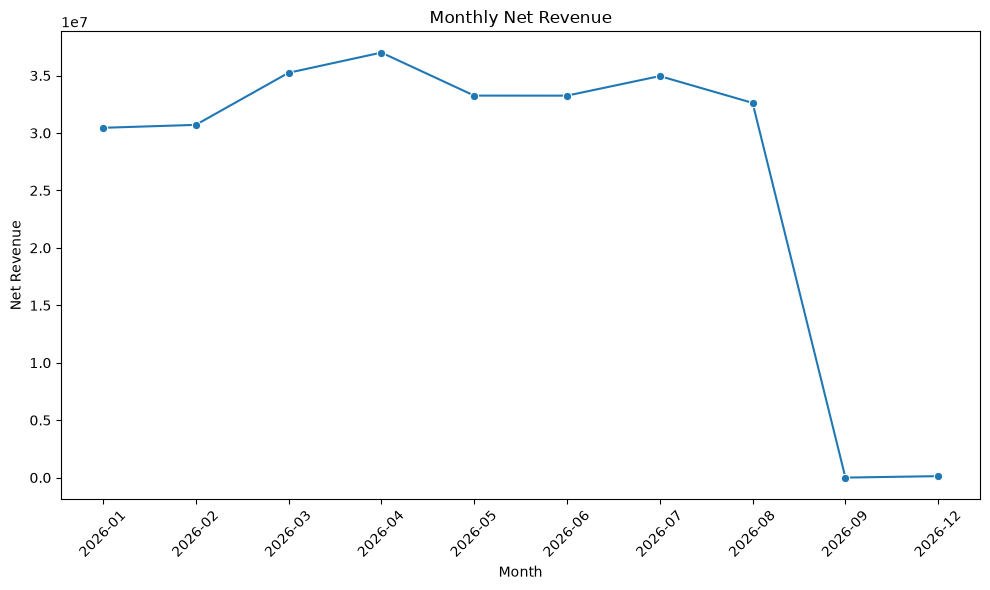

In [50]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_sales,
    x="Order_Date",
    y="Net_Revenue",
    marker="o"
)

plt.title("Monthly Net Revenue")
plt.xlabel("Month")
plt.ylabel("Net Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../charts/monthly_net_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.2 Monthly Profit

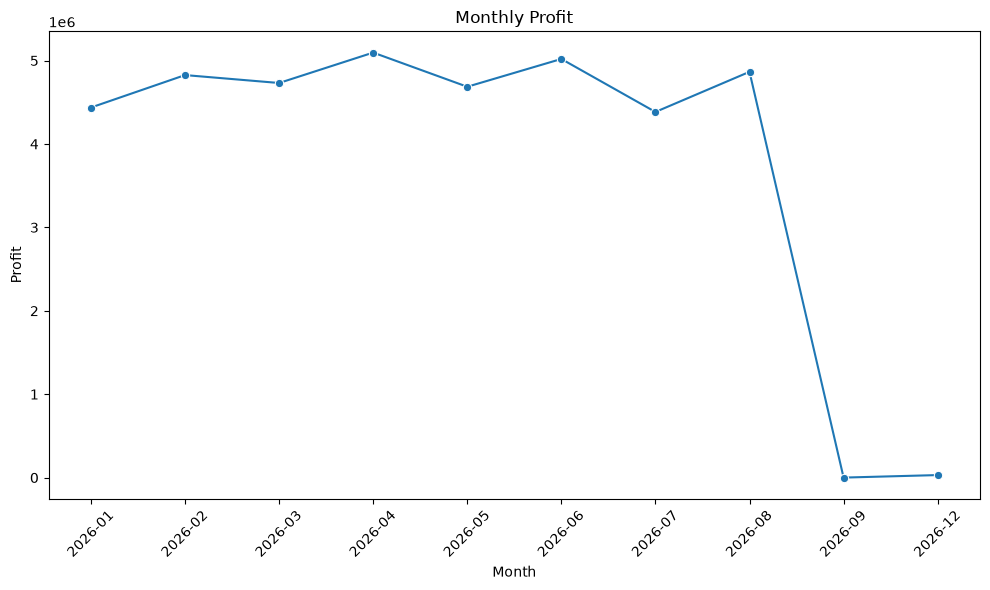

In [51]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_sales,
    x="Order_Date",
    y="Profit",
    marker="o"
)

plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../charts/monthly_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.3 Top 10 Products by Net Revenue

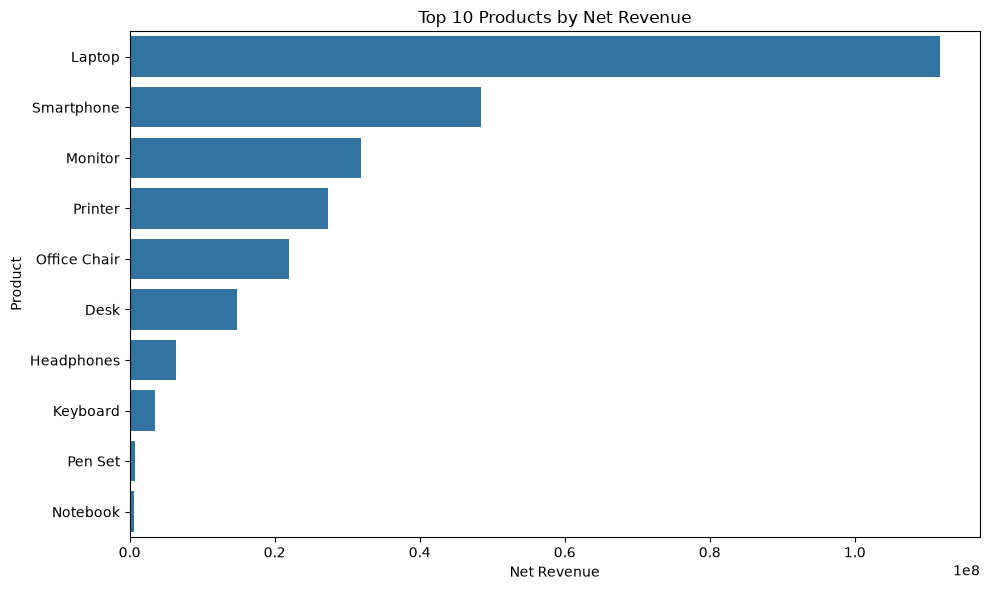

In [52]:
top_10_products = (
    product_analysis
    .sort_values("Net_Revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_products,
    x="Net_Revenue",
    y="Product"
)

plt.title("Top 10 Products by Net Revenue")
plt.xlabel("Net Revenue")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "../charts/top_10_products_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.4 Category Performance

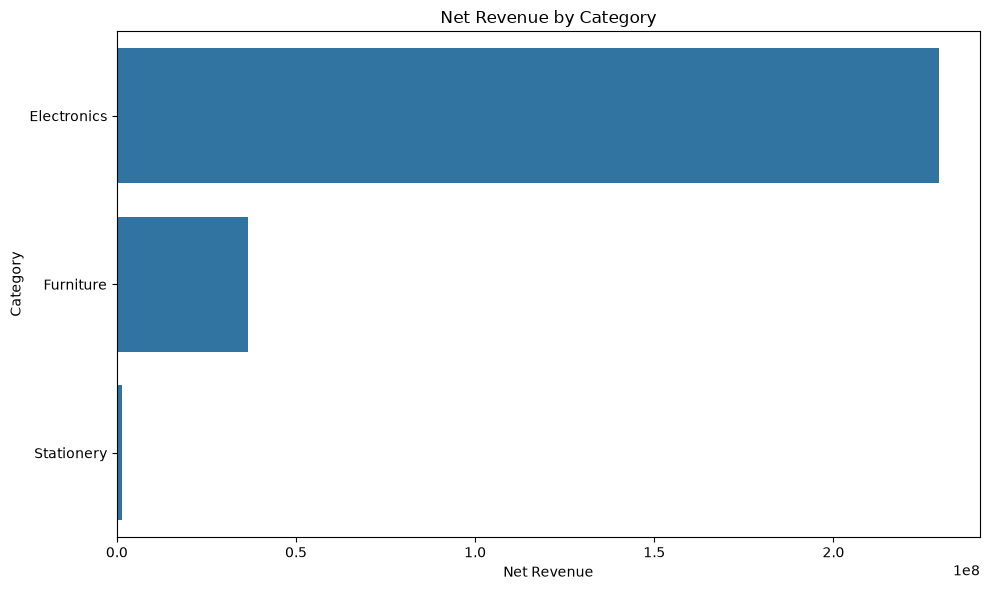

In [53]:
category_plot = (
    category_analysis
    .sort_values("Net_Revenue", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_plot,
    x="Net_Revenue",
    y="Category"
)

plt.title("Net Revenue by Category")
plt.xlabel("Net Revenue")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "../charts/category_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.5 Regional Performance

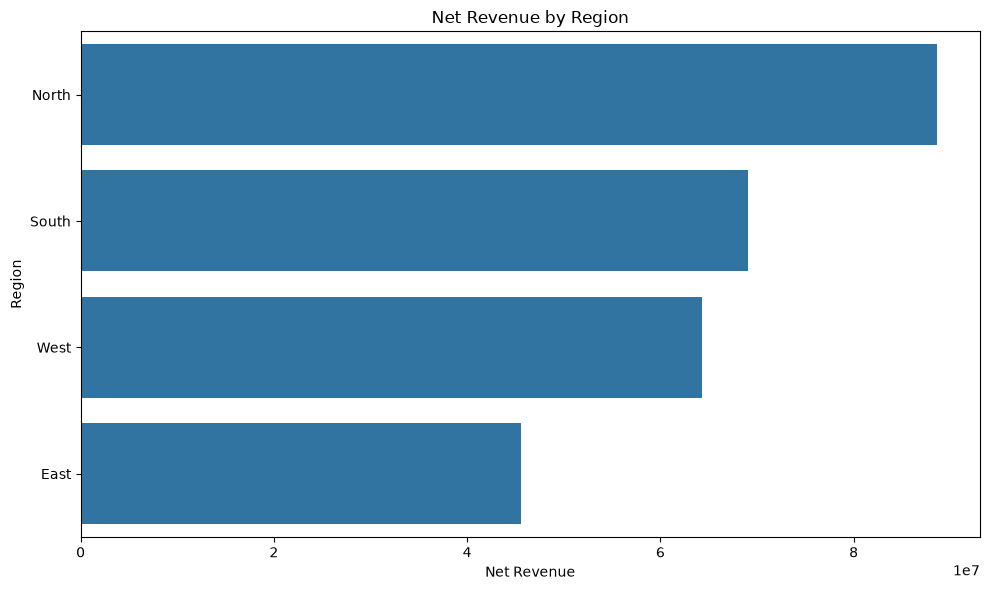

In [54]:
region_plot = (
    region_analysis
    .sort_values("Net_Revenue", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_plot,
    x="Net_Revenue",
    y="Region"
)

plt.title("Net Revenue by Region")
plt.xlabel("Net Revenue")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    "../charts/regional_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.6 Salesperson Performance


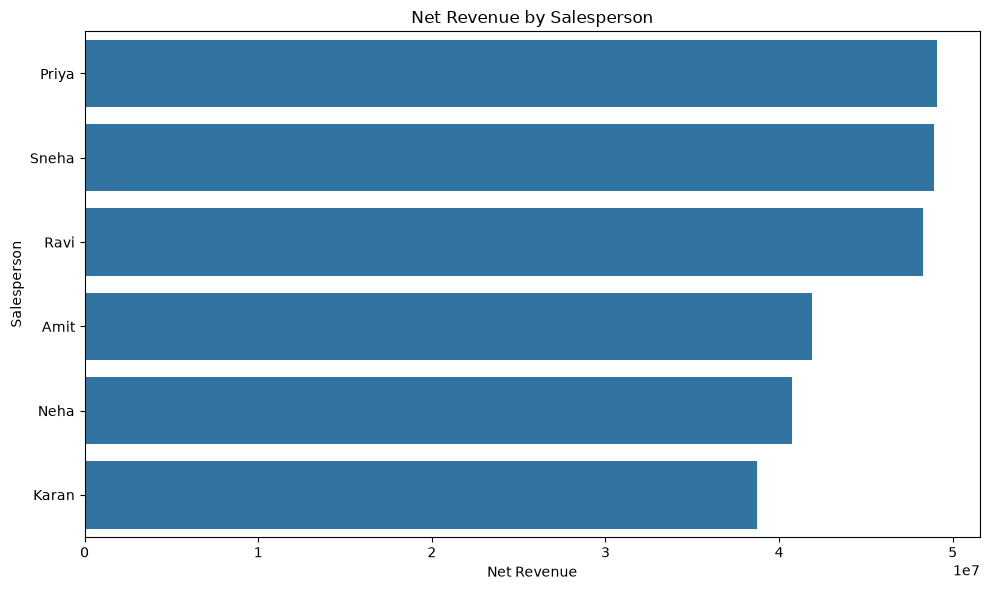

In [55]:
salesperson_plot = (
    salesperson_analysis
    .sort_values("Net_Revenue", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=salesperson_plot,
    x="Net_Revenue",
    y="Salesperson"
)

plt.title("Net Revenue by Salesperson")
plt.xlabel("Net Revenue")
plt.ylabel("Salesperson")

plt.tight_layout()

plt.savefig(
    "../charts/salesperson_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.7 Top 10 Customers

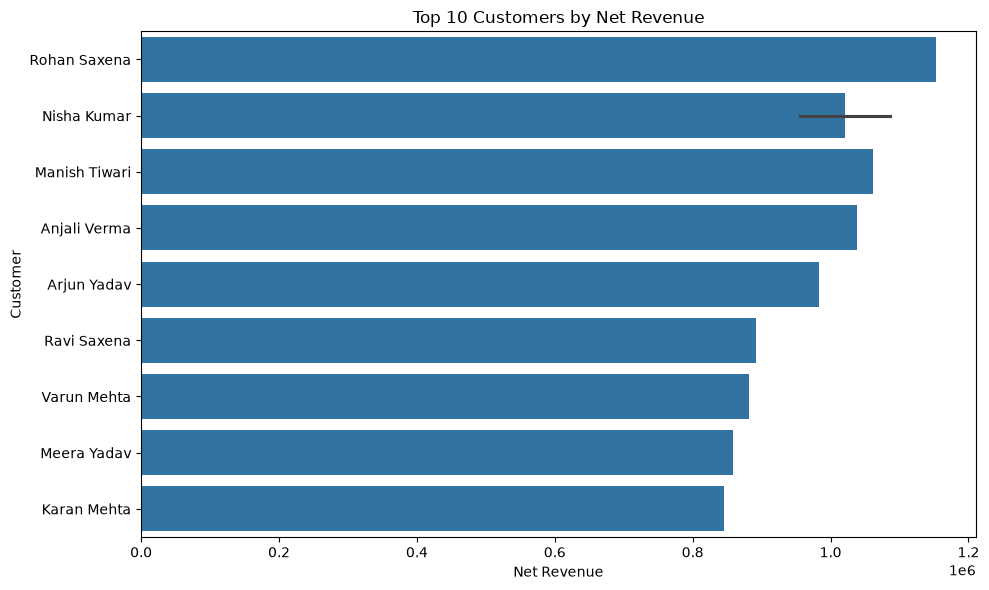

In [56]:
top_10_customers = (
    customer_analysis
    .sort_values("Net_Revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_customers,
    x="Net_Revenue",
    y="Customer_Name"
)

plt.title("Top 10 Customers by Net Revenue")
plt.xlabel("Net Revenue")
plt.ylabel("Customer")

plt.tight_layout()

plt.savefig(
    "../charts/top_10_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.8 — PAYMENT MODE

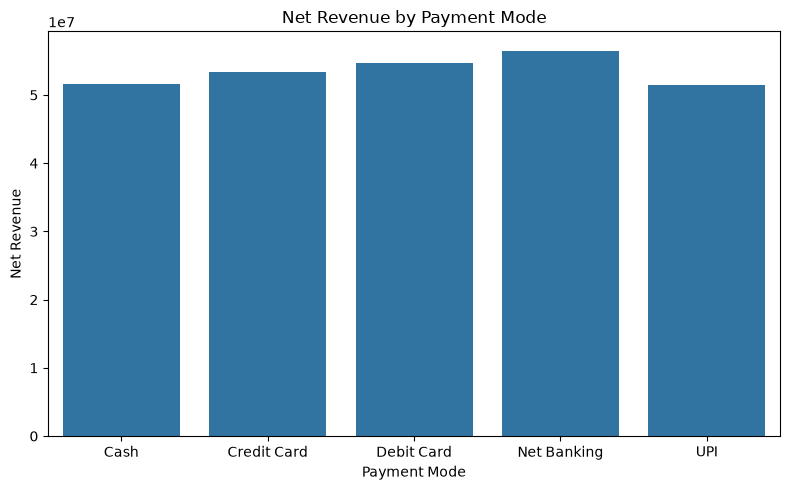

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=payment_analysis,
    x="Payment_Mode",
    y="Net_Revenue"
)

plt.title("Net Revenue by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Net Revenue")

plt.tight_layout()

plt.savefig(
    "../charts/payment_mode_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.9 — DISCOUNT IMPACT

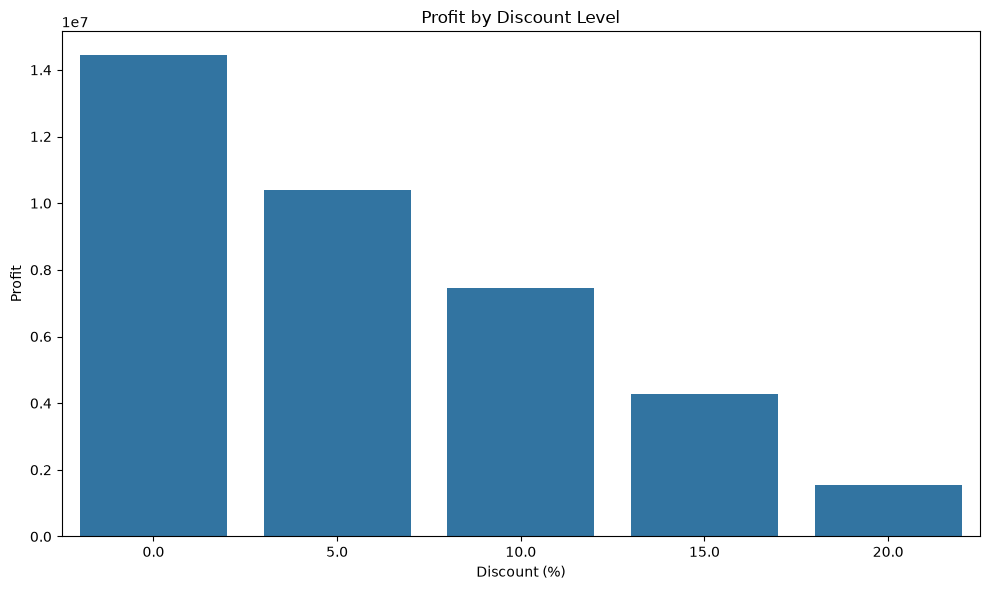

In [58]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=discount_analysis,
    x="Discount",
    y="Profit"
)

plt.title("Profit by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig(
    "../charts/discount_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 11. Business Insights

## Overall Business Performance

Best product by revenue

In [59]:
best_product = product_analysis.loc[
    product_analysis["Net_Revenue"].idxmax()
]

best_product

Product               Laptop
Orders                   584
Units_Sold            2428.0
Gross_Revenue    123265350.0
Net_Revenue      111683693.0
Profit            10994103.0
Profit_Margin       9.843964
Name: 3, dtype: object

Best product by profit

In [60]:
best_profit_product = product_analysis.loc[
    product_analysis["Profit"].idxmax()
]

best_profit_product

Product               Laptop
Orders                   584
Units_Sold            2428.0
Gross_Revenue    123265350.0
Net_Revenue      111683693.0
Profit            10994103.0
Profit_Margin       9.843964
Name: 3, dtype: object

Best category

In [61]:
best_category = category_analysis.loc[
    category_analysis["Net_Revenue"].idxmax()
]

best_category

Category         Electronics
Orders                  3041
Units_Sold           12243.0
Gross_Revenue    253770390.0
Net_Revenue      229434715.5
Profit            28755260.5
Profit_Margin       12.53309
Name: 0, dtype: object

Best region

In [62]:
best_region = region_analysis.loc[
    region_analysis["Net_Revenue"].idxmax()
]

best_region

Region                North
Orders                 1658
Units_Sold           6739.0
Net_Revenue      88641741.5
Profit           12658576.5
Profit_Margin     14.280604
Name: 1, dtype: object

Best salesperson

In [63]:
best_salesperson = salesperson_analysis.loc[
    salesperson_analysis["Net_Revenue"].idxmax()
]

best_salesperson

Salesperson           Priya
Orders                  865
Units_Sold           3441.0
Net_Revenue      49114230.5
Profit            6859290.5
Profit_Margin     13.965994
Name: 3, dtype: object

In [64]:

best_salesperson

Salesperson           Priya
Orders                  865
Units_Sold           3441.0
Net_Revenue      49114230.5
Profit            6859290.5
Profit_Margin     13.965994
Name: 3, dtype: object

Best customer

In [65]:
best_customer = customer_analysis.loc[
    customer_analysis["Net_Revenue"].idxmax()
]

best_customer

Customer_ID             C0373
Customer_Name    Rohan Saxena
Orders                      9
Units_Bought             39.0
Net_Revenue         1153065.0
Profit               162960.0
Profit_Margin       14.132768
Name: 380, dtype: object

### Calculate discount impact

In [66]:
discount_impact = total_revenue - total_net_revenue

discount_percentage = (
    discount_impact / total_revenue
) * 100

print("Revenue reduced by discounts:",
      round(discount_impact, 2))

print("Percentage of gross revenue given as discounts:",
      round(discount_percentage, 2), "%")

Revenue reduced by discounts: 28568737.5
Percentage of gross revenue given as discounts: 9.65 %


### Master summary table

In [67]:
business_summary = {
    "total_orders": int(total_orders),
    "total_units": int(total_units),
    "gross_revenue": float(total_revenue),
    "net_revenue": float(total_net_revenue),
    "total_cost": float(total_cost),
    "net_profit": float(total_net_profit),
    "net_profit_margin": float(net_profit_margin),
    "average_net_order_value": float(average_net_order_value),
    "best_product": best_product["Product"],
    "best_product_revenue": float(best_product["Net_Revenue"]),
    "best_product_profit": float(best_product["Profit"]),
    "best_category": best_category["Category"],
    "best_region": best_region["Region"],
    "best_salesperson": best_salesperson["Salesperson"],
    "best_customer": best_customer["Customer_Name"]
}


In [68]:

business_summary

{'total_orders': 5000,
 'total_units': 20103,
 'gross_revenue': 296176220.0,
 'net_revenue': 267607482.5,
 'total_cost': 229533135.0,
 'net_profit': 38074347.5,
 'net_profit_margin': 14.227684197881127,
 'average_net_order_value': 53521.4965,
 'best_product': 'Laptop',
 'best_product_revenue': 111683693.0,
 'best_product_profit': 10994103.0,
 'best_category': 'Electronics',
 'best_region': 'North',
 'best_salesperson': 'Priya',
 'best_customer': 'Rohan Saxena'}

# Executive Summary

## Overall Performance

- The dataset contains 5,000 sales transactions.
- Total units sold: 20,103.
- Gross revenue: ₹296.18 million.
- Net revenue after discounts: ₹267.61 million.
- Total cost: ₹229.53 million.
- Net profit: ₹38.07 million.
- Net profit margin: 14.23%.
- Average net order value: ₹53,521.50.

## Sales Trends

- April 2026 was the strongest complete month in the available dataset.
- September and December contain very few transactions and should be treated as incomplete periods rather than genuine low-performing months.

## Product Performance

- Laptop is the leading product by net revenue and profit.
- Smartphone is the second-largest revenue contributor.
- Notebook generates relatively low revenue but has an unusually high profit margin.

## Business Areas

- Category, regional, customer, and salesperson analysis identifies the strongest contributors to revenue and profit.
- Payment-mode analysis shows how customers prefer to complete transactions.
- Discount analysis helps evaluate the relationship between discount levels and profitability.

## Key Business Considerations

- Management should protect the performance of high-revenue products such as Laptop.
- High-margin but low-revenue products should be investigated for opportunities to increase sales.
- Discount strategies should be evaluated based on their effect on net revenue and profit rather than revenue alone.
- Customer and regional concentration should be monitored to identify growth opportunities and business risks.

Save our business summary

In [69]:
import json

with open("../data/business_summary.json", "w") as file:
    json.dump(business_summary, file, indent=4)

print("Business summary saved successfully.")

Business summary saved successfully.
